# TP2

- Clément RENIERS
- Louison PARANT

In [1]:
import numpy as np
np.set_printoptions(threshold=10000,suppress=True)
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('./villes.csv', sep=';')
X = data.iloc[:, 1:13].values
labels = data.iloc[:, 0].values

In [26]:
import sklearn as sk
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# print(X_scaled)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)

# print(pca.explained_variance_ratio_)

print("Il suffit de {} composantes pour expliquer 90% de la variance.".format(pca.n_components_))
print("Le premier axe contient {:.2f}% de la variance.".format(pca.explained_variance_ratio_[0] * 100))
print("Le deuxième axe contient {:.2f}% de la variance.".format(pca.explained_variance_ratio_[1] * 100))

Il suffit de 2 composantes pour expliquer 90% de la variance.
Le premier axe contient 87.27% de la variance.
Le deuxième axe contient 11.72% de la variance.


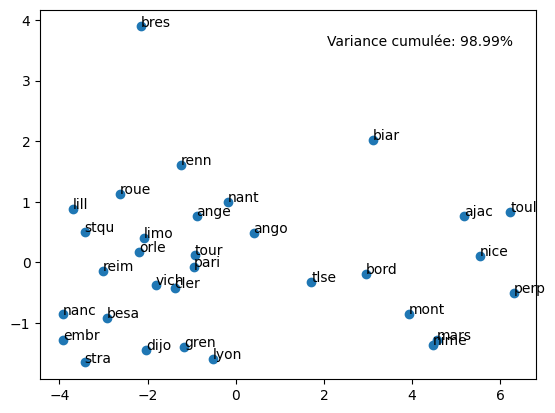

In [25]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
for l, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(l, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')
plt.annotate("Variance cumulée: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100), xy=(2, 3.5), textcoords='offset points')
plt.show()

On peut essayer de trouver plusieurs groupes : 
- Les villes tempérées : Ajaccio, Toulon, Nice, Perpignan, Toulouse, Montpellier, Marseille
- La ville froide : Brest
- La ville parfait : Biarritz :)

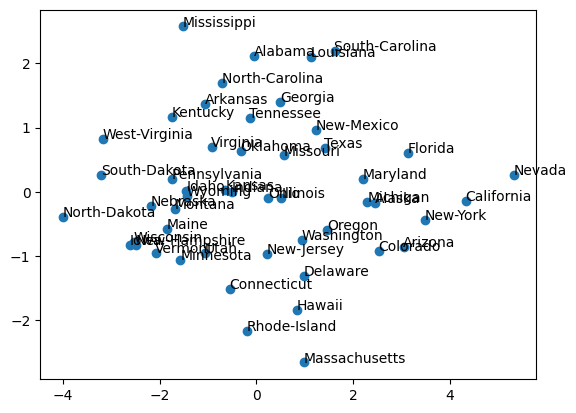

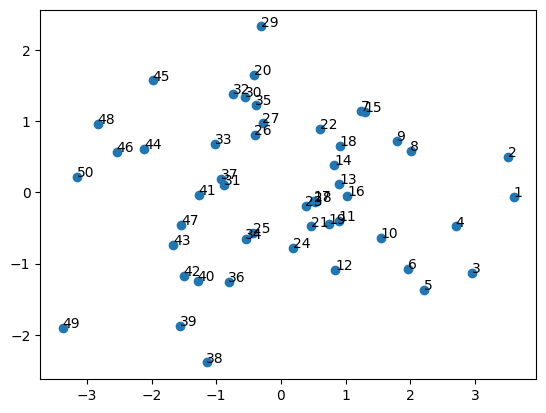

In [28]:
def graph(csv_filename: str):
    data = pd.read_csv(csv_filename, sep=';')
    X = data.iloc[:, 1:13].values
    labels = data.iloc[:, 0].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=0.9)
    X_pca = pca.fit_transform(X_scaled)

    plt.scatter(X_pca[:, 0], X_pca[:, 1])
    for l, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        plt.annotate(l, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')
    plt.annotate("Variance cumulée: {:.2f}%".format(pca.explained_variance_ratio_.sum() * 100), xy=(2, 3.5), textcoords='offset points')
    plt.show()

graph('crimes.csv')
graph('50_Startups.csv')